### Volumetric rate R(z) introdution

The volumetric rate of a transient corresponds to the expected rate of transients at a given redshift. Essentially, when we look into higheher redshifts we are looking at a **larger** volume of the universe which should contain more transients. However, whith higher redshift we also look at **earlier** moments of the universe where transients will not have had enough time to evolve so the relationship is not linear. Most rates take a shape that follows some evolution function $\phi_k$ normalized to the local observed rate $R_0$:
$$
R_k(z) = R_{0,k}\times \phi_k(z)\;;\;R(z\sim0)\sim R_{0,k}
$$


With this rate volution you can compute the total number of transients in a time window $\Delta t$ up to a redshift $z_{max}$ with:

$$
N_k(z<=z_{max}) = \int_0^{z_{max}} \frac{R_k(z)}{1+z}\frac{dV}{dz}dz
$$
Here $dV/dz$ corresponds to the co-moving volume element, and the $1/(1+z)$ factor appears as an effect of time dilation. 

Each transient type has a different formation mechanism, so the reltionship with the volumetric rate will change. These are also not all well-understood, and right now we ae making the following assumptions:

#### Local Rate $R_0$
The local rate of transients is derived from observations of classified objects. We will be mainly using the Bright Transient Survey from the ZTF telescope ([Perley et al 2020](https://arxiv.org/abs/2009.01242v2)), which observed and classified all transients  in  the ZTF footprint up to a limiting magnitude of $M=18.5$. The survey was abler to probe SN CC up to $z<0.05$, and SN Ia up to $z<0.1$. We take this estimation for obtaining the local rate of SN CC, SN Ia, SN Ib/c, and SN IIn. They were able to also estimate an **upper limit** on kilonovae rate, which we takea as the local rate

For Tidal Disruption Events (TDEs), the local rate is less understood as there have been fewere drtections. We just take an estimation from (Sun et al 2015)[https://arxiv.org/abs/1509.01592v1]. 

The values local rate values can be seen in the `params.py` file. 

#### Core-collapse Supernovae (Ib, Ic, II)
Supernovae occur from the collapse of massive stars, and since these are short-lived we expect in an area with a high star-fornmation rate to have high supernovae rate. Therefore, we assume that supernovae in the universe follow the **Star formation rate**. This can be maseured for galaxies, specifically the model from [Madau & Dickinson 2014](http://arxiv.org/abs/1403.0007v3) is the one we use, and its defined as:
$$
R_{SFR}(z) = R_0 \times \phi_0 \;;\;\phi_0 = 0.0068\times 0.015\frac{(1+z)^{2.7}}{1+[(1+z)/2.9]^{5.6}}\;[\text{yr}^{-1}\text{Mpc}^{-3}]
$$

#### Supernovae Ia

Supernove of type Ia arise from thermonuclear runnaway explosions when a white dwarf surpasses the Chandrasekhar mass. Currentl, there are two main production mechanisms for this type of reation: a white dwarf + star binary, where the white dwarf is accreting material from the companion, and a white dwarf - white dwarf binary that mergers. 

White dwarfs are progenited from stellar-mass like stars, which evolve over much larger timescales than massive stars. Therefore, there is an extra time delay we need t o take into account egtween the star formation and the thermal explosion. The rate model usually loosly follows the star formation rate with  an exrtra time-delay component ([Scannapeico & Bildsten 2005](https://iopscience.iop.org/article/10.1086/452632))
$$
R_{Ia} = A\times M_* + B\times SFR
$$

This, however, is not yet implemented int he  simulation. For now we are assuming that they follow  the star formation rate same as core-collapse supernovae, with their estiamted local rate $R_{0,SN\,Ia}$. 

#### Tidal Disruption Events
Tidal disruption events ocur when a star gets tidally disrupped by a supermassive black hole in the nucleous of galaxies (sometimes reffered to as nuclear transients). Theyr'e evolution is not weel understood, but (Sun et al 2015)[https://arxiv.org/abs/1509.01592v1] estimated it from simulations as:
$$
\phi_{TDE}(z) = \Bigg[(1/z)^{0.2\eta}+\Big(\frac{1+z}{1.43} \Big)^{-3.2\eta}+\Big(\frac{1+z}{2.66}\Big)^{-0.7\eta}]^{1/\eta}\;;\;\eta=-2
$$

#### Kilonovae
The leading production mechanism for a kilonovae is the merging of two neutron star (Binary neustorn star: BNS) or a neutron star - black hole (BHNS). Similar to Ia, there is a time delay expected from the formation of a system of two compact objects and the inspiral time until the merger (which is expected to dominate). Kilonovae are also thought to be associated with the emission of a short gama-ray burst (sGRB), as the famouse BNS event GW170817 had a sGRB and kilonova-like counterpart detected. 

Again, the evolution of these is not well understood, however (Sun et al 2015)[https://arxiv.org/abs/1509.01592v1] also presented 3 estimates for the evolution of sGRB as a function of redshift (gaussian, log-normal, and  power-law). We take the gaussian model as the volumetric rate evolution for kilonovae. 

$$
\phi_{\mathrm{sGRB}}(z) = \left[ (1+z)^{5.0\eta} + \left( \frac{1+z}{0.17} \right)^{0.87\eta} + \left( \frac{1+z}{4.12} \right)^{-8.0\eta} + \left( \frac{1+z}{4.05} \right)^{-20.5\eta} \right]^{\frac{1}{\eta}}\;;\;\eta=-2
$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.insert(1, '../.')
from transient_rates import plot_rates, R_SFR, R_TDE, R_sGRB_gaus
from params import p_cosmology

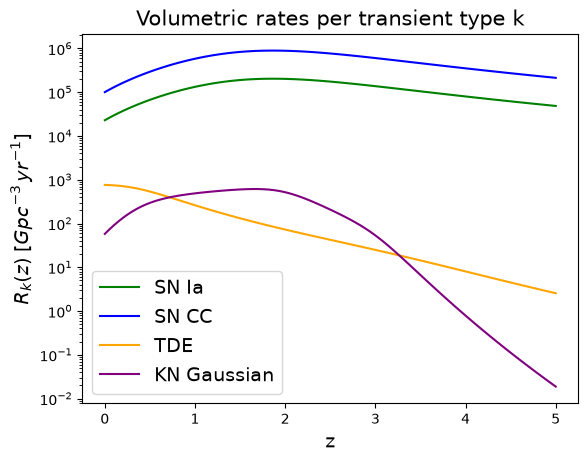

In [2]:
plot_rates()

And we also have the local rates defined in params.py

In [3]:
p_cosmology['R0']

{'SN Ia': <Quantity 23000. 1 / (yr Gpc3)>,
 'SN CC': <Quantity 101000. 1 / (yr Gpc3)>,
 'SN Ibc': <Quantity 101000. 1 / (yr Gpc3)>,
 'SN II': <Quantity 101000. 1 / (yr Gpc3)>,
 'TDE': <Quantity 800. 1 / (yr Gpc3)>,
 'KN': <Quantity 59.3 1 / (yr Gpc3)>}

The rate evolution functions are defiend in `transient_rates.py`. To see the evolution of one case, for example SN Ia we can use the SN Ia local rate and the star formation rate.

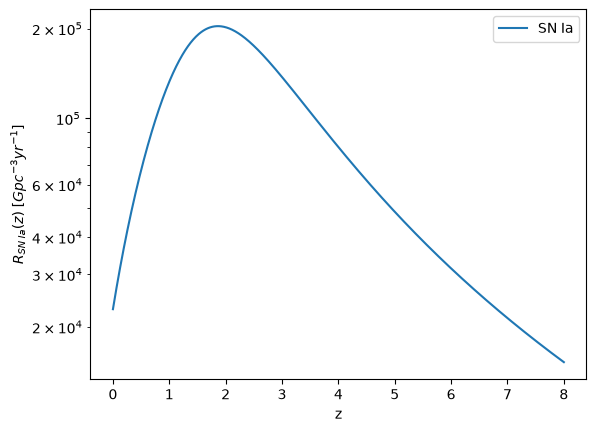

In [4]:
z_range = np.linspace(0, 8, 1000)
r_z = R_SFR(z_range, R0=p_cosmology['R0']['SN Ia'])

plt.plot(z_range, r_z, label='SN Ia')
plt.xlabel('z')
plt.ylabel(r'$R_{SN\;Ia}(z)\;[Gpc^{-3}yr^{-1}]$')
plt.legend()
plt.yscale('log')
plt.show()


When simulating transients, we can sample from this distribution

In [5]:
def sample_redshift_from_Rz(N, R_z, z_max=10, p_cosmology=p_cosmology):
    '''
    Params
    ------
    N: int, total number of redshifts to sample 
    R_z: func, volumetric rate evolution  function that takes as arguments R_z(z, R0). since we are normalizing the distirbution, R0 can be set to 1. 
    z_max: int, maximum redshift to sample from. z_mibn is defined in the parameter dictionary p_cosmology
    p_cosmology: dict, cosmological parameters used for integration. We just take z_min from this
    
    '''
    z_grid = np.linspace(p_cosmology['z_min'], z_max, 100000)
    rates_k = R_z(z_grid)

    p_k = rates_k / np.sum(rates_k)
    redshift_sample = np.random.choice(z_grid, p=p_k, size=N)
    return redshift_sample

In [6]:
sample_redshift_from_Rz(1, R_SFR)

array([2.0987])

If we then sample a large number of redshifts, we should see the sape of the R(z) appear if we overplot them together. 

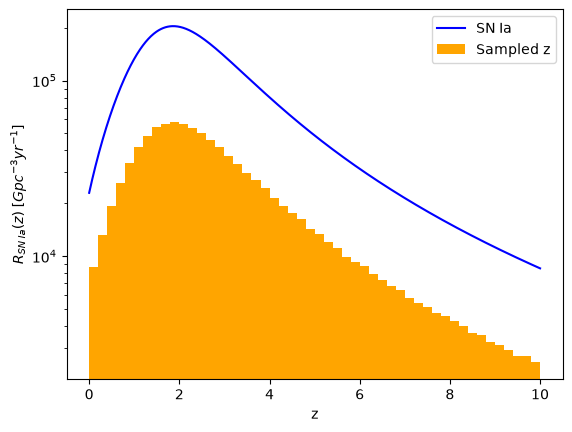

In [7]:
sampled_z = sample_redshift_from_Rz(1000000, R_SFR)

z_range = np.linspace(0, 10, 1000)
r_z = R_SFR(z_range, R0=p_cosmology['R0']['SN Ia'])

plt.plot(z_range, r_z, label='SN Ia', c='blue')
plt.hist(sampled_z, bins=50, color='orange', label='Sampled z')
plt.xlabel('z')
plt.ylabel(r'$R_{SN\;Ia}(z)\;[Gpc^{-3}yr^{-1}]$')
plt.legend()
plt.yscale('log')
plt.show()

In [9]:
from transient_rates import get_N_k, R_SFR
from astropy import units as u

In [14]:
get_N_k(R_SFR, z_max = 10, R0 = p_cosmology['R0']['SN Ia'], time_window = 10*u.yr + 100*u.d, sky_area = 4*np.pi*u.sr)

<Quantity 9.39551662e+08>

In [ ]:
# make sure you randomise the sky coords to within bottom half of sky since u halved the Vc

# diff t0 at diff skylocs and diff z
# with these t0, you now have lsst observing strategy to get how many detections we get in a [year] with all these transients.

# so of this sample, what is the average n_detections per SN and per redshift bin.

# and in total, we can see on average, how many per year you can classify

# night averages

# in a night, how many do you detect, how many active transients do you detect over a full year

# first night of LSST had 800000 detections --> mostly asteroids and stars. A lot of looping to do
# so we will need to find a way to restrict everything.

Tomorrow: ask Akshai more on choices of parameters in our upcoming simulations